In [418]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [419]:
df = pd.read_csv('spotify_churn_dataset.csv')

In [420]:
df.sample(10)

,user_id,subscription_type,country,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login,churned
877,user_878,Premium,FR,168.9,0,Electronic,1,0,27,0
355,user_356,Premium,DE,113.3,7,Country,4,0,13,0
385,user_386,Premium,PK,137.7,6,Hip-Hop,9,1,2,0
296,user_297,Free,IN,69.1,0,Electronic,4,0,20,0
90,user_91,Premium,IN,105.9,5,Electronic,0,0,16,0
847,user_848,Free,RU,65.7,2,Classical,5,0,0,0
417,user_418,Free,IN,-27.6,1,Jazz,11,1,5,1
183,user_184,Free,PK,78.5,0,Country,10,0,22,0
692,user_693,Free,PK,34.6,0,Electronic,1,1,2,1
607,user_608,Premium,DE,101.5,2,Country,1,0,38,0


In [421]:
df.shape

(1000, 10)

In [422]:
df.columns

Index(['user_id', 'subscription_type', 'country', 'avg_daily_minutes',
       'number_of_playlists', 'top_genre', 'skips_per_day', 'support_tickets',
       'days_since_last_login', 'churned'],
      dtype='object')

In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                1000 non-null   object 
 1   subscription_type      1000 non-null   object 
 2   country                1000 non-null   object 
 3   avg_daily_minutes      1000 non-null   float64
 4   number_of_playlists    1000 non-null   int64  
 5   top_genre              1000 non-null   object 
 6   skips_per_day          1000 non-null   int64  
 7   support_tickets        1000 non-null   int64  
 8   days_since_last_login  1000 non-null   int64  
 9   churned                1000 non-null   int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 78.3+ KB


In [424]:
df.describe()

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,97.442100,3.434000,4.631000,0.232000,9.496000,0.186000
std,42.916587,2.324015,2.777148,0.514238,9.742017,0.389301
min,-37.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.900000,1.000000,3.000000,0.000000,2.000000,0.000000
50%,97.900000,3.000000,5.000000,0.000000,7.000000,0.000000
75%,129.750000,5.000000,6.000000,0.000000,14.000000,0.000000
max,237.800000,10.000000,14.000000,2.000000,58.000000,1.000000


In [425]:
(df.isna().sum()/len(df))*100

user_id                  0.0
subscription_type        0.0
country                  0.0
avg_daily_minutes        0.0
number_of_playlists      0.0
top_genre                0.0
skips_per_day            0.0
support_tickets          0.0
days_since_last_login    0.0
churned                  0.0
dtype: float64

In [426]:
df.isna().sum()

user_id                  0
subscription_type        0
country                  0
avg_daily_minutes        0
number_of_playlists      0
top_genre                0
skips_per_day            0
support_tickets          0
days_since_last_login    0
churned                  0
dtype: int64

In [427]:
unique_countries = df['country'].unique()
print(unique_countries)

['US' 'PK' 'DE' 'IN' 'UK' 'BR' 'FR' 'CA' 'RU' 'AU']


In [428]:
df.columns

Index(['user_id', 'subscription_type', 'country', 'avg_daily_minutes',
       'number_of_playlists', 'top_genre', 'skips_per_day', 'support_tickets',
       'days_since_last_login', 'churned'],
      dtype='object')

In [429]:
subsciption = df['subscription_type'].map({'Free': 0, 'Premium': 1})
print(type(subsciption))
subsciption

<class 'pandas.core.series.Series'>


0      1
1      1
2      0
3      1
4      1
      ..
995    0
996    1
997    1
998    0
999    1
Name: subscription_type, Length: 1000, dtype: int64

In [430]:
(subsciption.value_counts()/subsciption.value_counts().sum())*100

subscription_type
1    61.7
0    38.3
Name: count, dtype: float64

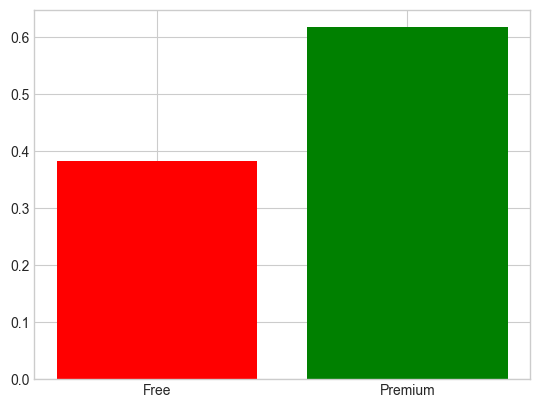

In [431]:
counts = (subsciption.value_counts()/subsciption.value_counts().sum()).sort_index()
plt.bar(['Free', 'Premium'], counts, color=['red', 'green'])
plt.show()

In [432]:
df.columns

Index(['user_id', 'subscription_type', 'country', 'avg_daily_minutes',
       'number_of_playlists', 'top_genre', 'skips_per_day', 'support_tickets',
       'days_since_last_login', 'churned'],
      dtype='object')

In [433]:
df['subscription_type'] = subsciption

In [434]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
country_encode = ohe.fit_transform(df[['country']])
country_encode

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(1000, 10))

In [435]:
country_df = pd.DataFrame(country_encode, columns=ohe.get_feature_names_out(['country']))
df = pd.concat([df.drop('country', axis=1), country_df], axis=1)
df

,user_id,subscription_type,avg_daily_minutes,number_of_playlists,top_genre,skips_per_day,support_tickets,days_since_last_login,churned,country_AU,country_BR,country_CA,country_DE,country_FR,country_IN,country_PK,country_RU,country_UK,country_US
0,user_1,1,134.9,4,Electronic,6,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,user_2,1,165.7,5,Pop,8,0,12,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,user_3,0,45.9,3,Classical,3,0,3,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,user_4,1,106.0,0,Jazz,7,0,3,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,user_5,1,89.6,5,Country,2,1,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,user_996,0,47.6,5,Hip-Hop,5,0,27,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
996,user_997,1,115.1,5,Country,2,0,4,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,user_998,1,89.5,6,Classical,0,0,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
998,user_999,0,33.2,3,Classical,5,0,15,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


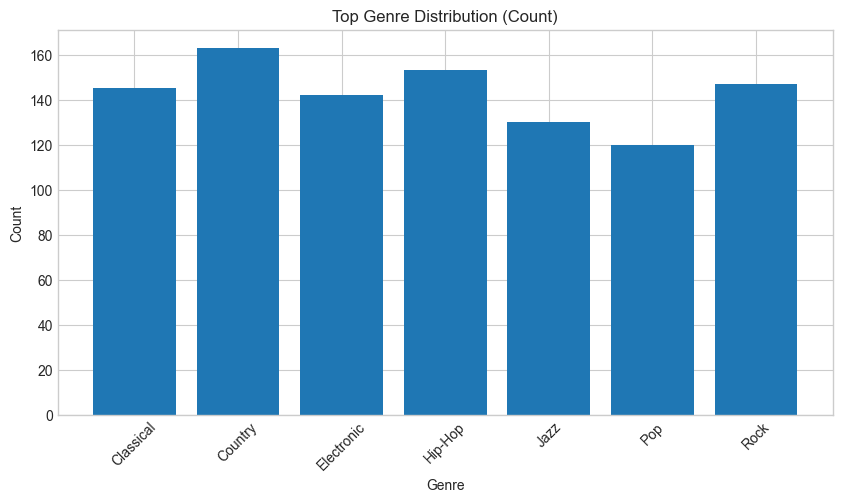

In [436]:
top = df['top_genre']
counts = top.value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title("Top Genre Distribution (Count)")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [437]:
top_genre = ohe.fit_transform(df[['top_genre']])
top_genre

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(1000, 7))

In [438]:
top_df = pd.DataFrame(top_genre, columns=ohe.get_feature_names_out(['top_genre']))
df = pd.concat([df.drop('top_genre', axis=1),top_df], axis=1)
df

,user_id,subscription_type,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned,country_AU,country_BR,...,country_RU,country_UK,country_US,top_genre_Classical,top_genre_Country,top_genre_Electronic,top_genre_Hip-Hop,top_genre_Jazz,top_genre_Pop,top_genre_Rock
0,user_1,1,134.9,4,6,0,1,0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,user_2,1,165.7,5,8,0,12,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,user_3,0,45.9,3,3,0,3,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,user_4,1,106.0,0,7,0,3,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,user_5,1,89.6,5,2,1,6,0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,user_996,0,47.6,5,5,0,27,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,user_997,1,115.1,5,2,0,4,0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
997,user_998,1,89.5,6,0,0,1,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
998,user_999,0,33.2,3,5,0,15,1,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [439]:
df = df[df['avg_daily_minutes'] >= 0]

In [440]:
from sklearn.preprocessing import StandardScaler

s = StandardScaler()
minutes = df['avg_daily_minutes']
minutes

0      134.9
1      165.7
2       45.9
3      106.0
4       89.6
       ...  
995     47.6
996    115.1
997     89.5
998     33.2
999     60.9
Name: avg_daily_minutes, Length: 993, dtype: float64

<Axes: ylabel='Frequency'>

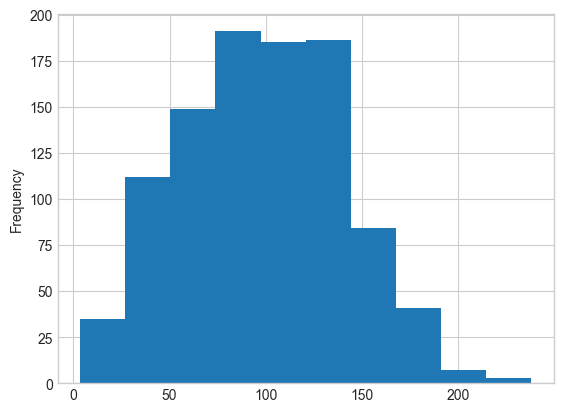

In [441]:
minutes.plot(kind='hist', bins=10)

In [442]:
minutes.skew()

np.float64(0.08578620024820736)

In [443]:
df['avg_daily_minutes'].min()
df[df['avg_daily_minutes'] < 0]

,user_id,subscription_type,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned,country_AU,country_BR,...,country_RU,country_UK,country_US,top_genre_Classical,top_genre_Country,top_genre_Electronic,top_genre_Hip-Hop,top_genre_Jazz,top_genre_Pop,top_genre_Rock


In [444]:
df['avg_daily_minutes'].min()

np.float64(3.6)

In [445]:
q1 = np.quantile(minutes, 0.25)
q3 = np.quantile(minutes, 0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = minutes[(minutes < lower_bound) |(minutes > upper_bound)]
outliers

57     235.6
757    237.8
Name: avg_daily_minutes, dtype: float64

<Axes: ylabel='Frequency'>

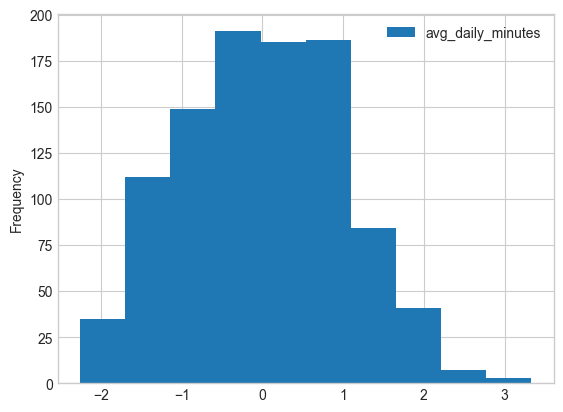

In [446]:
minutes = s.fit_transform(df[['avg_daily_minutes']])
minutes_df = pd.DataFrame(minutes, columns=['avg_daily_minutes'])
minutes_df.plot(kind='hist', bins=10)

In [447]:
minutes_df.skew()

avg_daily_minutes    0.085786
dtype: float64

In [448]:
df = df.reset_index(drop=True)
minutes_df = minutes_df.reset_index(drop=True)

df = pd.concat([df.drop('avg_daily_minutes', axis=1), minutes_df], axis=1)

In [449]:
df

,user_id,subscription_type,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned,country_AU,country_BR,country_CA,...,country_UK,country_US,top_genre_Classical,top_genre_Country,top_genre_Electronic,top_genre_Hip-Hop,top_genre_Jazz,top_genre_Pop,top_genre_Rock,avg_daily_minutes
0,user_1,1,4,6,0,1,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.874136
1,user_2,1,5,8,0,12,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.608908
2,user_3,0,3,3,0,3,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.249070
3,user_4,1,0,7,0,3,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.184690
4,user_5,1,5,2,1,6,0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.206552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,user_996,0,5,5,0,27,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.208515
989,user_997,1,5,2,0,4,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.401782
990,user_998,1,6,0,0,1,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.208938
991,user_999,0,3,5,0,15,1,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.552045


In [450]:
days = df['days_since_last_login']
days

0       1
1      12
2       3
3       3
4       6
       ..
988    27
989     4
990     1
991    15
992     1
Name: days_since_last_login, Length: 993, dtype: int64

In [458]:
import seaborn as sns

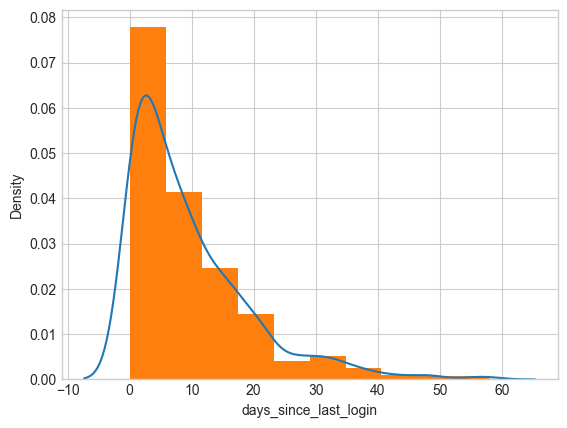

In [460]:
sns.kdeplot(days)
plt.hist(days, density=True)
plt.show()

In [452]:
days.skew()

np.float64(1.7015522229519375)

In [454]:
q1 = np.quantile(days, 0.25)
q3 = np.quantile(days, 0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

outliers = days[(days < lower_bound) |(days > upper_bound)]
outliers

10     34
29     35
50     33
63     37
95     34
132    40
163    41
206    43
208    35
222    34
244    58
249    34
266    37
278    35
288    35
323    47
332    48
344    33
348    41
380    48
426    41
435    38
466    49
535    33
552    37
602    38
631    37
694    55
715    58
719    36
730    45
774    39
811    36
826    49
915    56
940    33
978    44
Name: days_since_last_login, dtype: int64

In [455]:
df['days_since_last_login'] = s.fit_transform(
    df[['days_since_last_login']]
)

In [456]:
df

,user_id,subscription_type,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned,country_AU,country_BR,country_CA,...,country_UK,country_US,top_genre_Classical,top_genre_Country,top_genre_Electronic,top_genre_Hip-Hop,top_genre_Jazz,top_genre_Pop,top_genre_Rock,avg_daily_minutes
0,user_1,1,4,6,0,-0.873810,0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.874136
1,user_2,1,5,8,0,0.253997,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.608908
2,user_3,0,3,3,0,-0.668754,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.249070
3,user_4,1,0,7,0,-0.668754,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.184690
4,user_5,1,5,2,1,-0.361171,0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.206552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,user_996,0,5,5,0,1.791915,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.208515
989,user_997,1,5,2,0,-0.566227,0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.401782
990,user_998,1,6,0,0,-0.873810,0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.208938
991,user_999,0,3,5,0,0.561580,1,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.552045


In [461]:
df.to_csv("cleaned_data.csv", index=False)